In [43]:
import pandas as pd
import openpyxl
import os
import glob, re
import matplotlib.pyplot as plt

In [44]:
def read_excel(files, sheet):
    dfs = []
    for file in files:
        data = pd.read_excel(file, sheet_name=sheet, index_col=0)
        name = os.path.splitext(os.path.basename(file))[0]
        data['model'] = name
        match = re.search(r'lr[\d.]+_(\d+)_', name)
        if match:
            data['epochs'] = int(match.group(1))
        match_model = re.search(r'model_.*?_e_(.*?)_lr', name)
        if match_model:
            data['id'] = match_model.group(1)
        dfs.append(data)
    df = pd.concat(dfs,ignore_index=True)
    return df

In [45]:
def arrange_data(df, error):
    df = df.pivot(index='model', columns='error', values=error)
    return df

In [46]:
def min_vals(df, error):
    df1 = df.apply(lambda x: pd.Series({'model':x.idxmin(), error:x.min()})).T
    return df1

In [47]:
path = "model_Fe_Si_B_260311/**/test_res/*_test.xlsx"

In [48]:
files = glob.glob(path, recursive=True)

In [49]:
df = read_excel(files, 'errors')
df = df[['id', 'epochs']+[c for c in df.columns if c not in ['id', 'epochs']]]
#df

In [90]:
def plot_global_error(dfs,x,y_cols, df_labels, titles, tag):
    fig, axes = plt.subplots(1,len(dfs), figsize=(10,6))

    if len(dfs) == 1:
        axes = [axes]

    handles =[]
    labels = []
    markers = {'mae': 'o', 'rmse': '^'}

    for i, group in enumerate(dfs):
        ax = axes[i]
        for df, df_label in zip(group, df_labels):
            for y in y_cols:
                label = f'{y}_{df_label}'
                line = ax.scatter(df[x], df[y], marker=markers.get(y,'o'), label=f'{y}_{df_label}')
                if label not in labels:
                    handles.append(line)
                    labels.append(label)
        ax.set_xlabel(f'{x}')
        ax.set_title(titles[i])
    
    if tag == 'energy':
        units = 'meV/atom'
    elif tag == 'force': 
        units = r'meV/$\AA$'
    
    fig.legend(handles, labels, loc='center right', fontsize=6.5)
    fig.suptitle(f'MAE and RMSE in {units} for {df_labels} model')

In [51]:
def plot_config_error(dfs, y, titles, error):
    fig, axes = plt.subplots(1, len(dfs), figsize=(10,6))
    if len(dfs) == 1:
        axes = [axes]

    for i, df in enumerate(dfs):
        ax = axes[i]
        for config, group in df.groupby('config'):
            n_config = group['n_configs'].iloc[0]
            label = f'{config} (n={n_config})'
            ax.scatter(group['epochs'], group[y],marker='o',label=label)
        ax.set_xlabel('Epochs')
        ax.set_title(titles[i])

        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels,handles))

        ax.legend(unique.values(), unique.keys(), fontsize=6)
    fig.suptitle(f'{error}_(meV/atom)')

In [70]:
#voy a generar un dataframe para cada modelo
scmace = df.query('id == "scmace"')
matpes = df.query('id == "matpes"')
scmace_nofe8b4 = df.query('id == "scmace_nofe8b4"')

In [72]:
scmace_test_e = scmace.query('error == "test_energy"')
scmace_train_e = scmace.query('error == "train_energy"')
matpes_test_e = matpes.query('error == "test_energy"')
matpes_train_e = matpes.query('error == "train_energy"')
scmace_test_f = scmace.query('error == "test_force"')
scmace_train_f = scmace.query('error == "train_force"')
matpes_test_f = matpes.query('error == "test_force"')
matpes_train_f = matpes.query('error == "train_force"')
scmace_nofe8b4_test_e = scmace_nofe8b4.query('error == "test_energy"')
scmace_nofe8b4_train_e = scmace_nofe8b4.query('error == "train_energy"')

In [54]:
#plot_global_error([[scmace_test_e, matpes_test_e], [scmace_train_e, matpes_train_e]], 'epochs', ['mae', 'rmse'], ['scmace', 'matpes'], ['Test data', 'Train data'])

In [109]:
df.query('epochs == 100 & error == ["test_energy", "train_energy"]').sort_values('mae', ascending=True)

,id,epochs,error,rmse,mae,r2,model
13,matpes,100,train_energy,100.094452,23.863738,0.951146,model_rnd_e_matpes_lr0.0001_100_10_test
12,matpes,100,test_energy,41.652997,24.019415,0.990589,model_rnd_e_matpes_lr0.0001_100_10_test
1,scmace_nofe8b4,100,train_energy,152.843047,87.474704,0.826808,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
5,scmace,100,train_energy,212.670122,104.387671,0.779457,model_rnd_e_scmace_lr0.0001_100_10_test
0,scmace_nofe8b4,100,test_energy,182.857256,111.988795,0.768530,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
4,scmace,100,test_energy,210.180375,124.774518,0.760373,model_rnd_e_scmace_lr0.0001_100_10_test


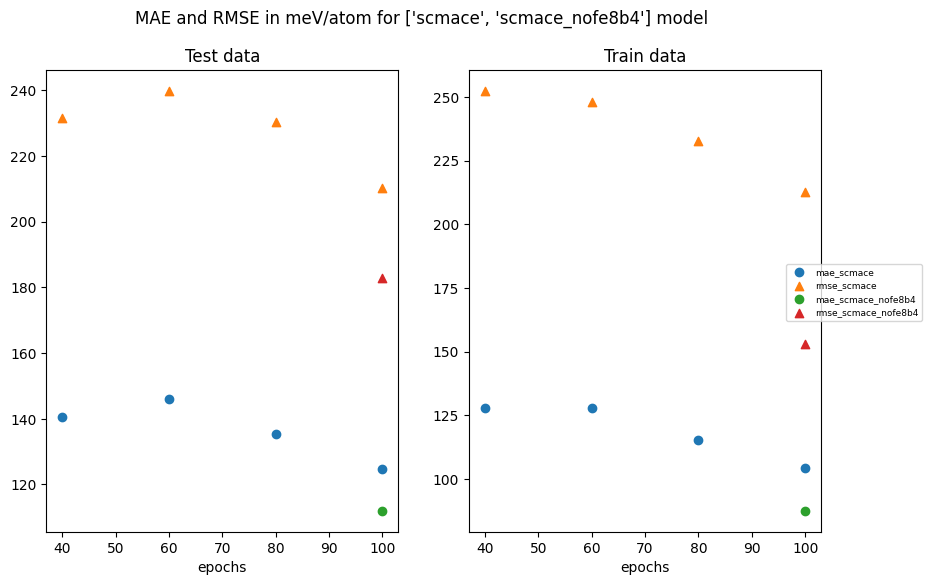

In [91]:
plot_global_error([[scmace_test_e, scmace_nofe8b4_test_e], [scmace_train_e, scmace_nofe8b4_train_e]], 'epochs', ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'energy')

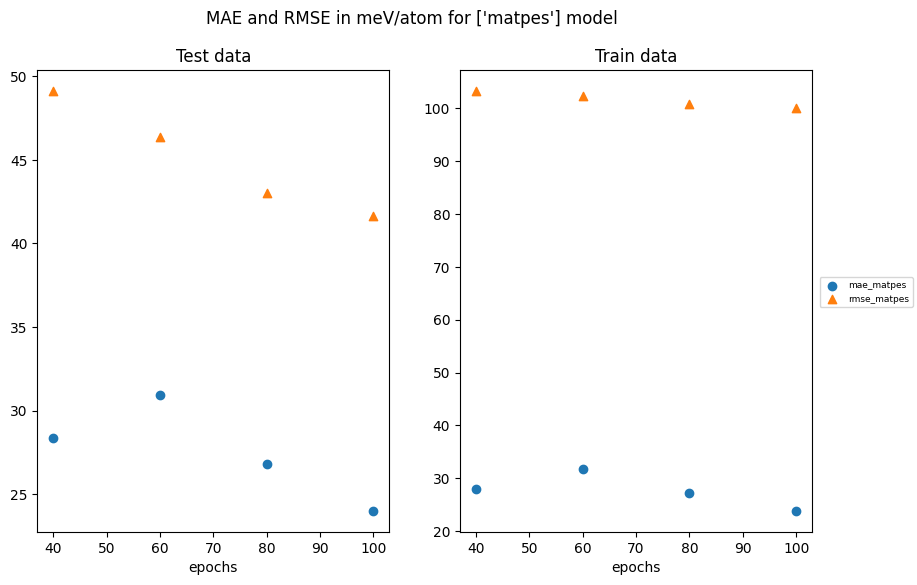

In [92]:
plot_global_error([[matpes_test_e], [matpes_train_e]], 'epochs', ['mae', 'rmse'], ['matpes'], ['Test data', 'Train data'], 'energy')

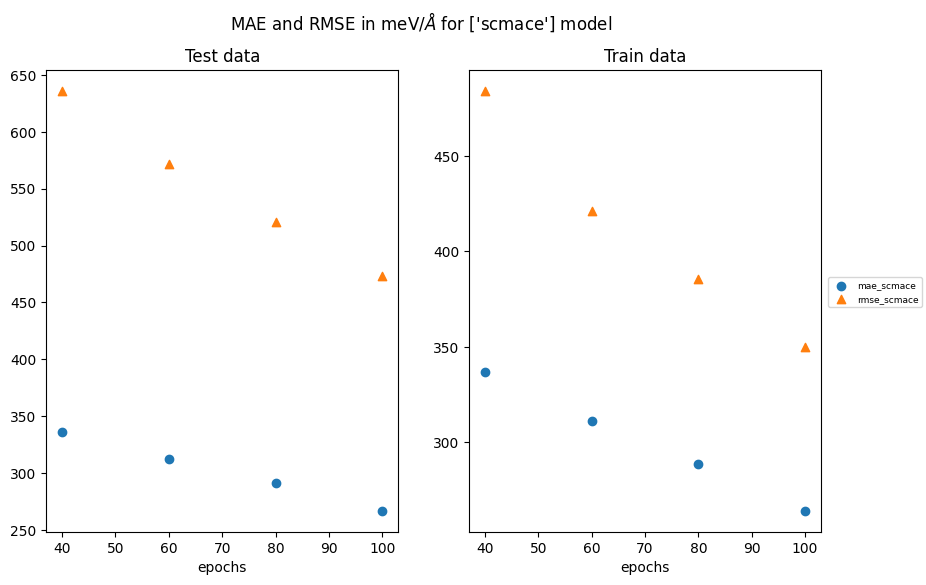

In [93]:
plot_global_error([[scmace_test_f], [scmace_train_f]], 'epochs', ['mae', 'rmse'], ['scmace'], ['Test data', 'Train data'], 'force')

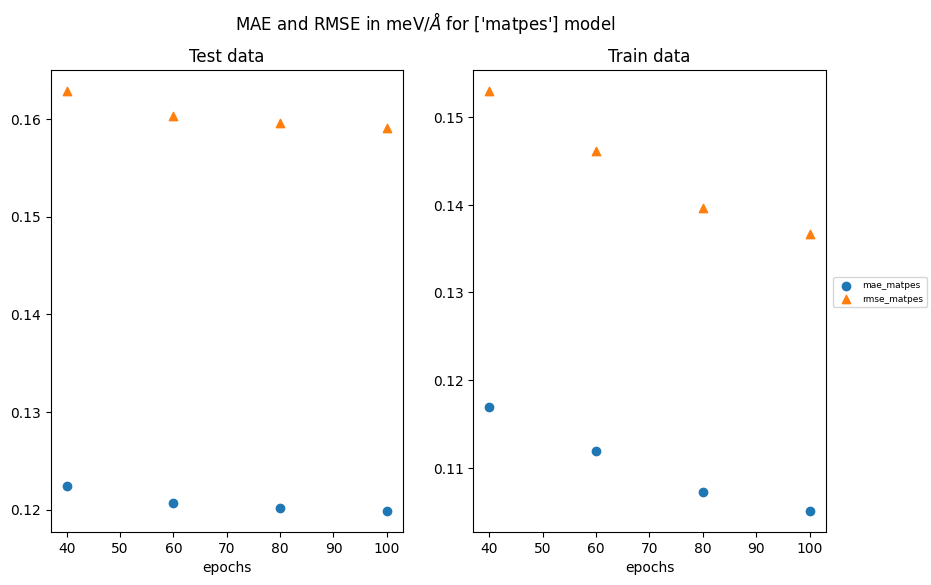

In [94]:
plot_global_error([[matpes_test_f], [matpes_train_f]], 'epochs', ['mae', 'rmse'], ['matpes'], ['Test data', 'Train data'], 'force')

In [95]:
rmse = arrange_data(df, 'rmse')
mae = arrange_data(df, 'mae')

In [96]:
min_vals(rmse, 'rsme')

,model,rsme
error,,
test_energy,model_rnd_e_matpes_lr0.0001_100_10_test,41.652997
test_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.159079
train_energy,model_rnd_e_matpes_lr0.0001_100_10_test,100.094452
train_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.136716


In [97]:
min_vals(mae, 'mae')

,model,mae
error,,
test_energy,model_rnd_e_matpes_lr0.0001_100_10_test,24.019415
test_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.119892
train_energy,model_rnd_e_matpes_lr0.0001_100_10_test,23.863738
train_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.105124


Reading the config errors

In [98]:
df_config =read_excel(files, 'config_errors')
df_config = df_config[['id', 'epochs', 'config', 'n_configs', 'mae', 'rmse', 'error', 'model']]
#df_config

In [99]:
scmace_config_test_e = df_config.query('id == "scmace" & error == "test_energy"')#.sort_values('mae', ascending=True)
scmace_config_train_e = df_config.query('id == "scmace" & error == "train_energy"')
matpes_config_test_e = df_config.query('id == "matpes" & error == "test_energy"')
matpes_config_train_e = df_config.query('id == "matpes" & error == "train_energy"')

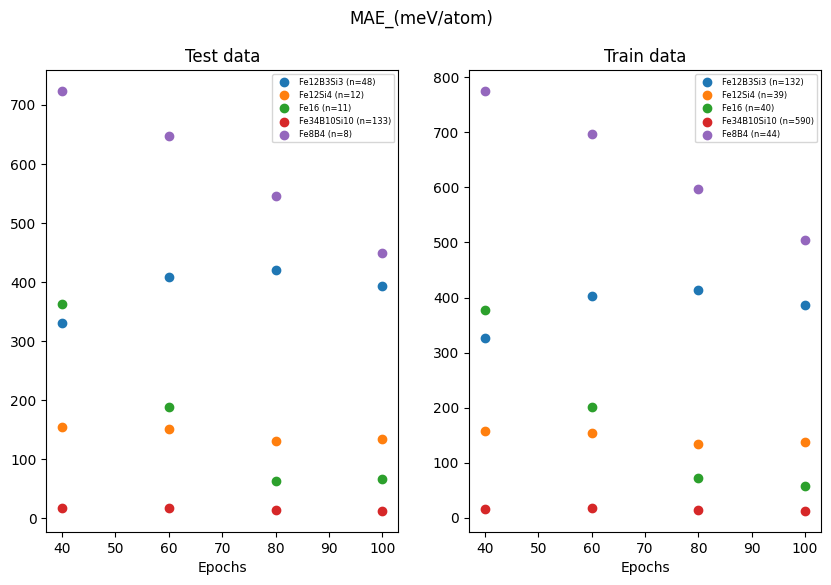

In [100]:
plot_config_error([scmace_config_test_e, scmace_config_train_e], 'mae', ['Test data', 'Train data'], 'MAE')

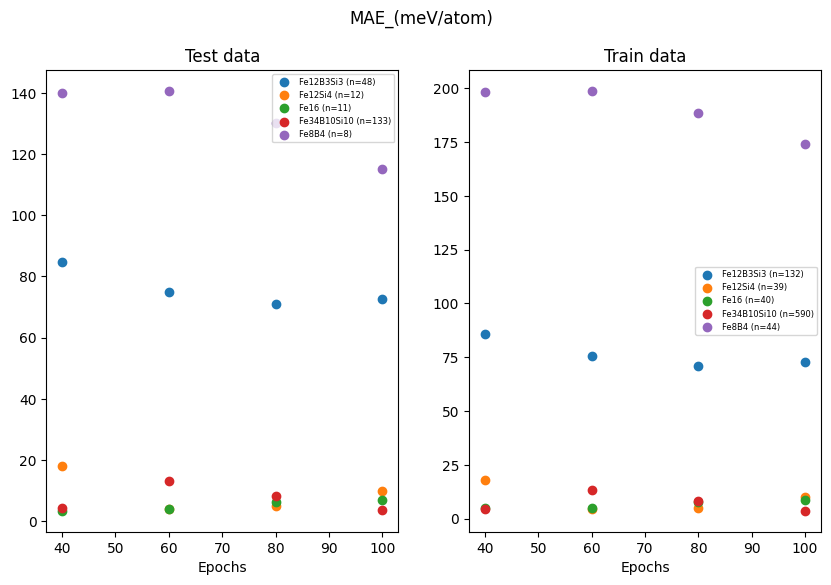

In [101]:
plot_config_error([matpes_config_test_e, matpes_config_train_e], 'mae', ['Test data', 'Train data'], 'MAE')

In [102]:
df_config.query('id == "scmace" & error == "train_energy"').sort_values('mae', ascending=True)

,id,epochs,config,n_configs,mae,rmse,error,model
16,scmace,100,Fe34B10Si10,590,12.430298,15.470571,train_energy,model_rnd_e_scmace_lr0.0001_100_10_test
76,scmace,80,Fe34B10Si10,590,13.863354,17.120244,train_energy,model_rnd_e_scmace_lr0.0001_80_10_test
86,scmace,40,Fe34B10Si10,590,16.111629,20.371132,train_energy,model_rnd_e_scmace_lr0.0001_40_10_test
66,scmace,60,Fe34B10Si10,590,17.171249,20.989510,train_energy,model_rnd_e_scmace_lr0.0001_60_10_test
15,scmace,100,Fe16,40,56.930606,66.693207,train_energy,model_rnd_e_scmace_lr0.0001_100_10_test
75,scmace,80,Fe16,40,71.874366,88.522012,train_energy,model_rnd_e_scmace_lr0.0001_80_10_test
74,scmace,80,Fe12Si4,39,133.545638,136.543100,train_energy,model_rnd_e_scmace_lr0.0001_80_10_test
14,scmace,100,Fe12Si4,39,137.138739,139.183731,train_energy,model_rnd_e_scmace_lr0.0001_100_10_test
64,scmace,60,Fe12Si4,39,154.173300,157.262401,train_energy,model_rnd_e_scmace_lr0.0001_60_10_test
84,scmace,40,Fe12Si4,39,156.856406,159.559893,train_energy,model_rnd_e_scmace_lr0.0001_40_10_test


In [103]:
df_config.query('id == "matpes" & error == "test_energy"').sort_values('mae', ascending=True)

,id,epochs,config,n_configs,mae,rmse,error,model
40,matpes,40,Fe16,11,3.363690,4.621235,test_energy,model_rnd_e_matpes_lr0.0001_40_10_test
31,matpes,100,Fe34B10Si10,133,3.642926,4.661568,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
50,matpes,60,Fe16,11,3.799697,4.854654,test_energy,model_rnd_e_matpes_lr0.0001_60_10_test
49,matpes,60,Fe12Si4,12,3.927227,4.348577,test_energy,model_rnd_e_matpes_lr0.0001_60_10_test
41,matpes,40,Fe34B10Si10,133,4.299808,5.523249,test_energy,model_rnd_e_matpes_lr0.0001_40_10_test
19,matpes,80,Fe12Si4,12,4.808195,5.172613,test_energy,model_rnd_e_matpes_lr0.0001_80_10_test
20,matpes,80,Fe16,11,6.094816,6.651858,test_energy,model_rnd_e_matpes_lr0.0001_80_10_test
30,matpes,100,Fe16,11,6.880569,7.642087,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
21,matpes,80,Fe34B10Si10,133,8.338329,9.337885,test_energy,model_rnd_e_matpes_lr0.0001_80_10_test
29,matpes,100,Fe12Si4,12,9.839741,10.007741,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test


In [104]:
df_config.query('id == "matpes" & error == "train_energy"').sort_values('mae', ascending=True)

,id,epochs,config,n_configs,mae,rmse,error,model
36,matpes,100,Fe34B10Si10,590,3.656830,4.759407,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
54,matpes,60,Fe12Si4,39,4.228887,4.652940,train_energy,model_rnd_e_matpes_lr0.0001_60_10_test
46,matpes,40,Fe34B10Si10,590,4.554277,5.775843,train_energy,model_rnd_e_matpes_lr0.0001_40_10_test
45,matpes,40,Fe16,40,4.875505,6.571228,train_energy,model_rnd_e_matpes_lr0.0001_40_10_test
24,matpes,80,Fe12Si4,39,4.905662,5.244371,train_energy,model_rnd_e_matpes_lr0.0001_80_10_test
55,matpes,60,Fe16,40,5.088528,6.387306,train_energy,model_rnd_e_matpes_lr0.0001_60_10_test
25,matpes,80,Fe16,40,7.774841,8.987460,train_energy,model_rnd_e_matpes_lr0.0001_80_10_test
26,matpes,80,Fe34B10Si10,590,8.296824,9.358866,train_energy,model_rnd_e_matpes_lr0.0001_80_10_test
35,matpes,100,Fe16,40,8.827048,10.186386,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
34,matpes,100,Fe12Si4,39,9.987663,10.192224,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
